# SpaceX S-1 — Space (launch) segment economics

Sibling to the Connectivity notebook. The Space segment is SpaceX's **launch business**: Falcon 9,
Falcon Heavy, and Dragon flown for commercial and government customers — plus the giant, mostly
invisible internal launch operation that deploys Starlink (and, soon, AI compute). On a GAAP basis
the segment *loses money*. This notebook argues that the loss is almost entirely a **Starship
development invoice**, that the underlying customer launch franchise is highly profitable, and then
models what Starship actually unlocks — and roughly when it can start paying for itself.

**Roadmap.**
1. **What the Space segment sells** — Launch Services (point-in-time) vs Launch & Development (over-time, government).
2. **The cadence engine** — a launch monopoly that mostly flies for *itself*; the revenue you don't see.
3. **Unit economics of the customer franchise** — \$/launch, the internal-cost gap.
4. **The GAAP loss is a Starship invoice** — strip R&D and the franchise earns ~\$1.5–1.9B.
5. **Starship: the cost-per-kg lever** — what a 99% cost collapse unlocks, and the accounting hinge.
6. **Modeling Starship revenue** — when it commercializes and what it's worth (bear/base/bull).
7. **Forward FCF** — R&D reversal + modest external lift → cash; squared with ``dcf.py``.

> **Finance terms, plain English.** *Operating income* = revenue minus the costs of running the
> business (incl. R&D), before interest and tax. *Capex* = cash spent on long-lived assets (rockets,
> tooling) that is *capitalized* (put on the balance sheet) and then *depreciated* (expensed a bit
> each year) rather than hitting the P&L all at once. *D&A* = that yearly depreciation charge. The
> Starship story below turns on one rule: today Starship is **expensed** as R&D; at commercialization
> it gets **capitalized** instead — a mechanical swing in reported profit.

In [1]:
# Locate the repo root (the directory containing `analysis/`) so imports work from anywhere.
import os
import sys

current_dir = os.getcwd()
repo_root = current_dir
while repo_root != os.path.dirname(repo_root):
    if os.path.isdir(os.path.join(repo_root, "analysis")):
        break
    repo_root = os.path.dirname(repo_root)

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from analysis import data, charts
from analysis.space_economics import (
    SpaceModel,
    PERIODS,
    PAYLOAD_T_LEO,
    COST_PER_KG,
    STARSHIP_RND_SHARE,
    STARSHIP_RND_SHARE_BAND,
)
from analysis.connectivity_economics import INTERNAL_LAUNCH_COST_M

charts.apply_style()

NAVY = charts.SEGMENT_COLORS["Space"]
TEAL = charts.SEGMENT_COLORS["Connectivity"]
ORANGE = charts.SEGMENT_COLORS["AI"]
GREY = charts.SEGMENT_COLORS["Total Reportable Segments"]

# Per-period Space fundamentals from the S-1 CSVs — every later calculation starts here.
R = SpaceModel().raw()


def fmt(df, pct=(), one=()):
    """Table display helper: percent for ratio cols, 1 decimal for per-launch cols, else $M integers."""
    format_spec = {}
    for column in df.columns:
        if column in pct:
            format_spec[column] = "{:.1%}"
        elif column in one:
            format_spec[column] = "{:,.1f}"
        elif pd.api.types.is_numeric_dtype(df[column]):
            format_spec[column] = "{:,.0f}"
    return df.style.format(format_spec)


R.T


period,FY2023,FY2024,FY2025,Q1-2026
revenue,3557.000000,3796.000000,4086.000000,619.000000
op_income,-1.000000,21.000000,-657.000000,-662.000000
cogs,1669.000000,1541.000000,1352.000000,281.000000
rnd,1538.000000,1835.000000,3004.000000,930.000000
sga,351.000000,375.000000,349.000000,70.000000
impairment,0.000000,24.000000,38.000000,0.000000
da,571.000000,637.000000,757.000000,166.000000
sbc,427.000000,472.000000,515.000000,145.000000
capex,1497.000000,2032.000000,3832.000000,1052.000000
adj_ebitda_reported,997.000000,1154.000000,653.000000,-351.000000


### Charting convention: the FY2026E estimate

We only have one quarter of fiscal 2026 (Q1, to Mar 31). Dropping that three-month stub next to full
years makes every time-series look like the business fell off a cliff, so for the **charts** we replace
it with a full-year estimate, **FY2026E**, built the same way the Connectivity notebook does it: grow
each FY2025 line item by its own **Q1-2026-over-Q1-2025 growth rate**. This is a mechanical run-rate
extrapolation — *if Q1's year-over-year pace holds, where does the full year land?* — not a bottom-up
forecast. FY2026E is drawn **hatched** in every chart to flag it as an estimate; the **tables keep the
actual reported quarter**.

The estimate already carries the §2 signal: customer launches are running *down* (7 vs 12 a year ago,
a ~25-launch full-year pace vs 43 in FY2025) while internal Starlink launches are running *up* (33 vs
24, a ~168 full-year pace vs 122). So on a run-rate basis customer Space revenue softens even as total
cadence and mass-to-orbit keep climbing — exactly the "fly more for ourselves" dynamic, not a decline
in the business.

In [2]:
# FY2026E — annualize the partial Q1-2026 quarter so time-series charts compare like with like.
# Method: grow each FY2025 line item by its own Q1-2026 / Q1-2025 (year-over-year) rate.
# Tables elsewhere keep the ACTUAL reported quarter; only the charts use this estimate.

Q = SpaceModel().raw(["Q1-2025", "Q1-2026"])
q1_2025 = Q.loc["Q1-2025"]
q1_2026 = Q.loc["Q1-2026"]
yoy = q1_2026 / q1_2025

fy26e = R.loc["FY2025"] * yoy
fy26e["impairment"] = 0.0

CHART_PERIODS = ["FY2023", "FY2024", "FY2025", "FY2026E"]


def to_chart(column_name):
    """Three reported full years from R + the FY2026E run-rate estimate."""
    reported_years = ["FY2023", "FY2024", "FY2025"]
    historical_values = list(R.loc[reported_years, column_name])
    estimated_value = fy26e[column_name]
    return historical_values + [estimated_value]


EST_PATCH = Patch(
    facecolor="0.9",
    edgecolor="#888",
    hatch="//",
    label="FY2026E (Q1-2026 run-rate est.)",
)

show_columns = [
    "revenue",
    "launch_services",
    "launch_dev",
    "customer_launches",
    "starlink_launches",
    "mass_to_orbit",
]
est = pd.DataFrame({
    "FY2025 (actual)": R.loc["FY2025", show_columns],
    "Q1 YoY growth": yoy[show_columns] - 1,
    "FY2026E (est.)": fy26e[show_columns],
})
fmt(est, pct=["Q1 YoY growth"])


,FY2025 (actual),Q1 YoY growth,FY2026E (est.)
revenue,"4,086",-28.4%,"2,924"
launch_services,"2,576",-41.7%,"1,502"
launch_dev,"1,510",-3.3%,"1,459"
customer_launches,43,-41.7%,25
starlink_launches,122,37.5%,168
mass_to_orbit,"2,213",23.6%,"2,734"


## 1. What the Space segment sells

Two revenue buckets, split by *how* the S-1 recognizes them (MD&A p.98):

- **Launch Services** — recognized *at a point in time*, when the customer's payload reaches orbit.
  This is the classic Falcon 9 / Falcon Heavy / Dragon mission sold to a commercial or government
  customer. Lumpy, per-launch, ~\$60M a flight.
- **Launch & Development** — recognized *over time* (cost-to-cost), tied to **long-term government
  contracts** (development programs, crew/cargo). Smoother, contract-driven. The S-1 explicitly
  expects this to grow as a *share* of Space revenue as the government backlog is worked off.

One caveat dominates everything that follows, and it's the same accounting fact the Connectivity
notebook leans on: **Space revenue reflects only *customer* activity.** Launches dedicated to
Starlink earn *no* inter-segment revenue here — their cost is capitalized into Connectivity instead.
So the Space P&L is the tip of the iceberg; most of the cadence is flown internally, for free.

,Launch Services,Launch & Development,Total Space revenue,Launch Services %
period,,,,
FY2023,"1,964","1,593","3,557",55.2%
FY2024,"2,584","1,212","3,796",68.1%
FY2025,"2,576","1,510","4,086",63.0%
Q1-2026,330,289,619,53.3%


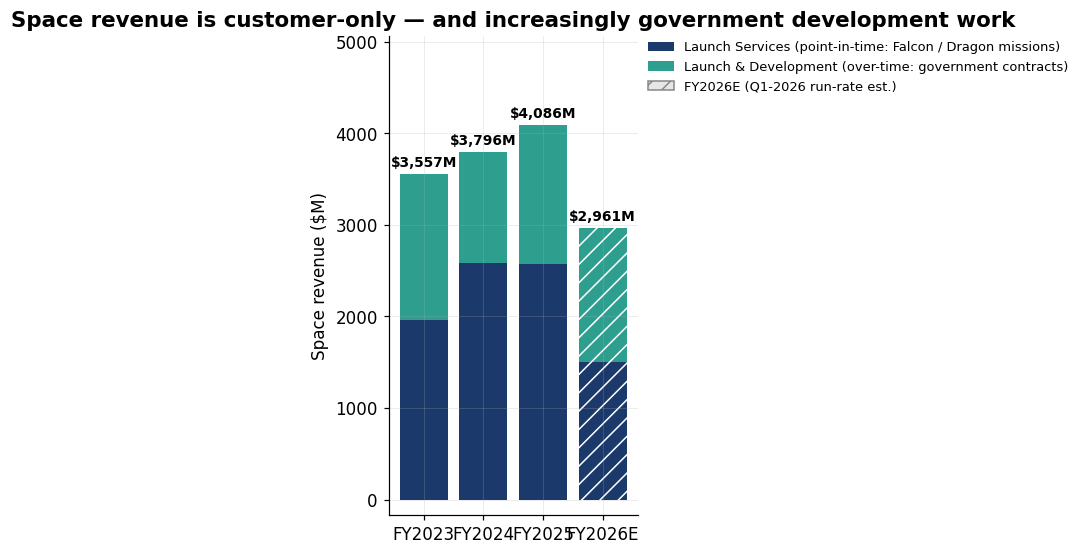

In [3]:
# Revenue recognition mix: Launch Services (point-in-time) vs Launch & Development (over-time).
split = pd.DataFrame({
    "Launch Services": R.launch_services,
    "Launch & Development": R.launch_dev,
})
split["Total Space revenue"] = split["Launch Services"] + split["Launch & Development"]
split["Launch Services %"] = R.ls_pct
display(fmt(split, pct=["Launch Services %"]))

# --- Chart: stacked revenue by recognition bucket ---
fig, ax = plt.subplots(figsize=(9.0, 5.2))
x_positions = np.arange(len(CHART_PERIODS))

launch_services_values = to_chart("launch_services")
launch_dev_values = to_chart("launch_dev")

bars_ls = ax.bar(
    x_positions,
    launch_services_values,
    color=NAVY,
    label="Launch Services (point-in-time: Falcon / Dragon missions)",
)
bars_ld = ax.bar(
    x_positions,
    launch_dev_values,
    bottom=launch_services_values,
    color=TEAL,
    label="Launch & Development (over-time: government contracts)",
)

# Mark the FY2026E bar (last bar) as an estimate.
for bar_group in (bars_ls, bars_ld):
    estimate_bar = bar_group[-1]
    estimate_bar.set_hatch("//")
    estimate_bar.set_edgecolor("white")
    estimate_bar.set_linewidth(0)

for period_index in range(len(CHART_PERIODS)):
    total_revenue = launch_services_values[period_index] + launch_dev_values[period_index]
    label_y = total_revenue + 80
    ax.text(
        period_index,
        label_y,
        f"${total_revenue:,.0f}M",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(CHART_PERIODS)
ax.set_ylabel("Space revenue ($M)")
ax.set_title("Space revenue is customer-only — and increasingly government development work")
charts.legend_outside(ax, loc="upper left", fontsize=8.5, handles=[bars_ls, bars_ld, EST_PATCH])
charts.finish(fig, rect=(0, 0, 0.82, 1))
charts.pad_ylim(ax, top=0.18)
charts.save(fig, "space_revenue_split", layout=False)
plt.show()


Customer Space revenue is nearly flat — **\$3.8B → \$4.1B** across FY2024–FY2025, and *down*
year-over-year in Q1-2026. For a company growing total revenue ~33%, that looks like stagnation. It
isn't: it's a deliberate choice to point the rocket inward (§2). Note too that **Launch &
Development** — the government contract book — is a third to a half of the segment and rising, exactly
as the S-1 guides. The customer launch business is real, but it is *not* where SpaceX's launch value
mostly shows up.

## 2. The cadence engine — a launch monopoly that mostly flies for itself

SpaceX put **>80% of the world's mass to orbit** in 2025 (S-1, p.80). Yet customer launches barely
moved — **33 → 45 → 43** Falcon flights for customers across FY2023–25 — while *internal* Starlink
launches went **63 → 89 → 122**. The binding constraint on Space revenue is **not** customer demand
or launch capacity; it's that SpaceX keeps absorbing its own capacity to deploy Starlink. The S-1 is
blunt: *"When an expected customer payload for a planned launch is not available, we instead use
launch capacity for our satellites,"* and *"we expect Space revenue growth to continue to be lower
than total company revenue growth as our internal business continues to absorb most of the growth in
our launch capacity."*

So the right way to see Space is as a **launch monopoly whose output is mostly consumed internally**.
The chart below splits the cadence; the table then values the *invisible* internal launches two ways —
at the price a customer would pay, and at SpaceX's internal cost — to size the revenue that never
appears on the Space P&L.

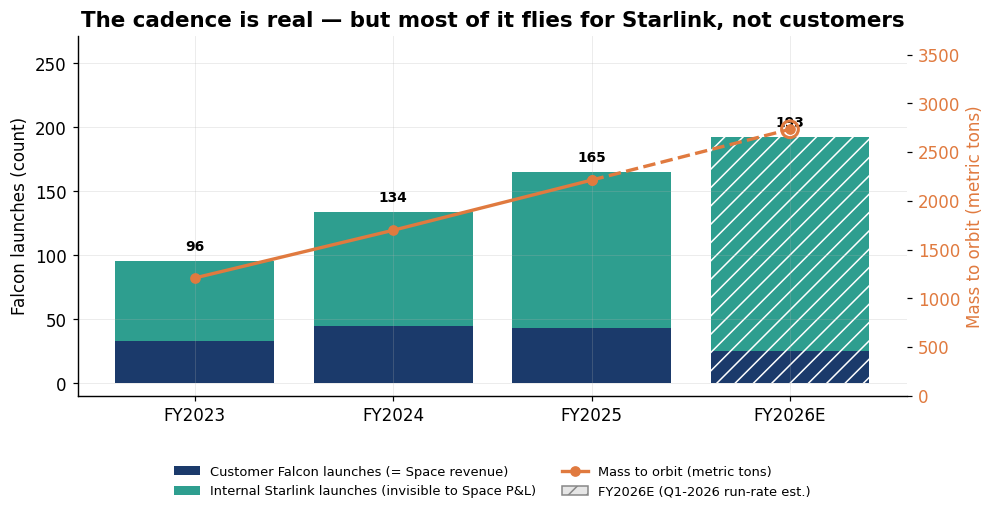

In [4]:
# Falcon cadence: customer vs internal Starlink launches, with mass-to-orbit overlaid.
fig, ax = plt.subplots(figsize=(9.2, 5.4))
x_positions = np.arange(len(CHART_PERIODS))

customer_launches = to_chart("customer_launches")
internal_launches = to_chart("starlink_launches")

bars_customer = ax.bar(
    x_positions,
    customer_launches,
    color=NAVY,
    label="Customer Falcon launches (= Space revenue)",
)
bars_internal = ax.bar(
    x_positions,
    internal_launches,
    bottom=customer_launches,
    color=TEAL,
    label="Internal Starlink launches (invisible to Space P&L)",
)

for bar_group in (bars_customer, bars_internal):
    estimate_bar = bar_group[-1]
    estimate_bar.set_hatch("//")
    estimate_bar.set_edgecolor("white")
    estimate_bar.set_linewidth(0)

total_launches = []
for period_index in range(len(CHART_PERIODS)):
    total = customer_launches[period_index] + internal_launches[period_index]
    total_launches.append(total)
    ax.text(period_index, total + 8, f"{total:.0f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x_positions)
ax.set_xticklabels(CHART_PERIODS)
ax.set_ylabel("Falcon launches (count)")
ax.set_ylim(0, max(total_launches) * 1.28)
ax.set_title("The cadence is real — but most of it flies for Starlink, not customers")

# Overlay mass-to-orbit on a second y-axis.
mass_values = to_chart("mass_to_orbit")
reported_x = x_positions[:3]
reported_mass = mass_values[:3]
estimated_x = x_positions[2:]
estimated_mass = mass_values[2:]

ax2 = ax.twinx()
ax2.plot(reported_x, reported_mass, color=ORANGE, marker="o", linewidth=2.2)
ax2.plot(estimated_x, estimated_mass, color=ORANGE, marker="o", linewidth=2.2, linestyle="--")
ax2.scatter(
    [x_positions[-1]],
    [mass_values[-1]],
    s=120,
    facecolors="none",
    edgecolors=ORANGE,
    linewidth=2,
    zorder=5,
)
ax2.set_ylabel("Mass to orbit (metric tons)", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)
ax2.grid(False)
ax2.set_ylim(0, max(mass_values) * 1.35)

mass_line = plt.Line2D(
    [],
    [],
    color=ORANGE,
    marker="o",
    linewidth=2.2,
    label="Mass to orbit (metric tons)",
)
legend_handles = [bars_customer, bars_internal, mass_line, EST_PATCH]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    fontsize=8.5,
    frameon=False,
)
charts.finish(fig, rect=(0, 0.08, 1.0, 1.0))
charts.pad_ylim(ax, top=0.10)
charts.save(fig, "space_cadence", layout=False)
plt.show()


In [5]:
# Value the invisible internal launches: at market price vs at internal cost ($17.5M).
market_price = R.launch_services / R.customer_launches

inv = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
inv["Customer launches"] = R.customer_launches
inv["Internal launches"] = R.starlink_launches
inv["Market $/launch"] = market_price
inv["Reported Space revenue"] = R.revenue

internal_at_market = R.starlink_launches * market_price
internal_at_cost = R.starlink_launches * INTERNAL_LAUNCH_COST_M
inv["Internal @ market (shadow)"] = internal_at_market
inv["Internal @ cost ($17.5M)"] = internal_at_cost
inv["Vertical-integration value"] = internal_at_market - internal_at_cost
inv["True launch output @ market"] = R.revenue + internal_at_market

display(fmt(inv, one=["Market $/launch"]))

shadow25 = inv.loc["FY2025", "Internal @ market (shadow)"]
true25 = inv.loc["FY2025", "True launch output @ market"]
reported25 = R.revenue["FY2025"]
capture_pct = reported25 / true25

print(
    f"FY2025: reported Space revenue ${reported25:,.0f}M captures only "
    f"{capture_pct:.0%} of the ~${true25:,.0f}M of launch SpaceX actually flew at market value."
)
print(
    f"        ${shadow25:,.0f}M of launch was consumed internally to deploy Starlink "
    f"(it lands in Connectivity's capitalized cost base at ${INTERNAL_LAUNCH_COST_M}M/launch, not as revenue)."
)


,Customer launches,Internal launches,Market $/launch,Reported Space revenue,Internal @ market (shadow),Internal @ cost ($17.5M),Vertical-integration value,True launch output @ market
period,,,,,,,,
FY2023,33,63,59.5,"3,557","3,749","1,102","2,647","7,306"
FY2024,45,89,57.4,"3,796","5,111","1,558","3,553","8,907"
FY2025,43,122,59.9,"4,086","7,309","2,135","5,174","11,395"
Q1-2026,7,33,47.1,619,"1,556",578,978,"2,175"


FY2025: reported Space revenue $4,086M captures only 36% of the ~$11,395M of launch SpaceX actually flew at market value.
        $7,309M of launch was consumed internally to deploy Starlink (it lands in Connectivity's capitalized cost base at $17.5M/launch, not as revenue).


The reported **\$4.1B** of FY2025 Space revenue is less than **40%** of the ~\$11B of launch SpaceX
actually flew if internal Starlink missions were priced at market. The other ~\$7B is *consumed
internally* — it shows up not as Space revenue but as a low (\$17.5M/launch) capitalized cost inside
Connectivity, which is precisely the launch-cost moat the Connectivity notebook quantified. **Space
is a monopoly that mostly subsidizes its own sister segment.** Judging it on its standalone P&L
misses the point of the vertical integration.

## 3. Unit economics of the customer launch franchise

Take the customer business on its own terms. Each customer Falcon mission sells for **~\$60M**
(Launch Services revenue ÷ customer launches — a blend of Falcon 9, Falcon Heavy, and Dragon), and
SpaceX's *internal* marginal cost of a reused Falcon 9 is **~\$17.5M** (triangulated in the
Connectivity notebook, §6: external estimates and the S-1's own Satellites PP&E line both land on the
\$15–20M band). That spread is the franchise. The point of this section isn't a precise margin — it's
that the **customer-facing launch business throws off cash**, which makes the segment's reported loss
(next section) all the more obviously a *choice*.

In [6]:
# Customer-franchise economics: revenue per launch vs internal cost, and the implied contribution.
fran = pd.DataFrame(index=pd.Index(PERIODS, name="period"))
fran["Customer launches"] = R.customer_launches
fran["Launch Services rev"] = R.launch_services
fran["Market $/launch"] = market_price
fran["Internal $/launch"] = INTERNAL_LAUNCH_COST_M

spread_per_launch = market_price - INTERNAL_LAUNCH_COST_M
margin_pct = 1 - INTERNAL_LAUNCH_COST_M / market_price
fran["Spread $/launch"] = spread_per_launch
fran["Implied launch margin %"] = margin_pct

display(fmt(fran, pct=["Implied launch margin %"], one=["Market $/launch", "Internal $/launch", "Spread $/launch"]))

print("Each customer flight sells for ~3-4x its internal cost. The customer launch franchise is")
print("structurally profitable; the segment-level loss below is created entirely downstream, by R&D.")


,Customer launches,Launch Services rev,Market $/launch,Internal $/launch,Spread $/launch,Implied launch margin %
period,,,,,,
FY2023,33,"1,964",59.5,17.5,42.0,70.6%
FY2024,45,"2,584",57.4,17.5,39.9,69.5%
FY2025,43,"2,576",59.9,17.5,42.4,70.8%
Q1-2026,7,330,47.1,17.5,29.6,62.9%


Each customer flight sells for ~3-4x its internal cost. The customer launch franchise is
structurally profitable; the segment-level loss below is created entirely downstream, by R&D.


A ~\$60M price on a ~\$17.5M internal cost is a **~70% gross spread** per flight (the reported
segment cost of revenue is higher because it carries second stages, launch operations, overhead, and
depreciation — but the marginal economics are unambiguous). The customer franchise is a cash machine.
Now watch it disappear into a loss.

## 4. The GAAP loss is a Starship invoice

Here is the central claim of the whole notebook. Walk the FY2025 Space P&L from the top:

| | \$M |
|---|---:|
| Revenue | 4,086 |
| − Cost of revenue | (1,352) |
| − SG&A | (349) |
| − Impairment | (38) |
| **= Core operating income (pre-R&D)** | **2,347** |
| − Research & development | (3,004) |
| **= Reported operating income** | **(657)** |

The launch-and-services operation earns **\$2,347M before R&D — a 57% margin.** The segment only
shows a loss because it then spends **\$3,004M on R&D**, and the S-1 tells us exactly what that is:
*"in 2025 we accelerated our timeline for Starship development, increasing R&D in our Space segment
to \$3,004 million, compared to \$1,835 million in 2024"* (the entire **\$1,169M** increase is
Starship), and *"A majority of Starship costs are currently expensed to Research and development as
incurred."*

So the right mental model isn't "money-losing launch segment." It's "**profitable launch franchise
writing a multi-billion-dollar check to build Starship.**" The bridge chart makes the size of that
check obvious; the sensitivity then asks what the franchise earns once Starship R&D normalizes.

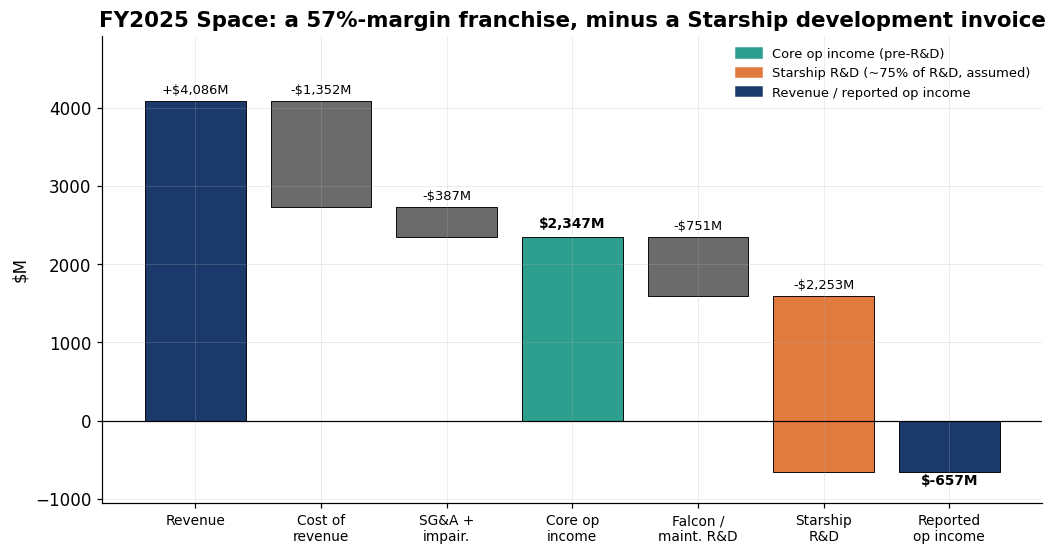

Core op income (pre-R&D): $2,347M (57% margin)  ->  after $3,004M R&D: $-657M


In [7]:
# Waterfall: from Space revenue down to the reported loss, isolating the Starship R&D "invoice".
period = "FY2025"

revenue = R.revenue[period]
cogs = R.cogs[period]
sga = R.sga[period]
impairment = R.impairment[period]
rnd = R.rnd[period]

core_operating_income = revenue - cogs - sga - impairment
starship_rnd = STARSHIP_RND_SHARE * rnd
falcon_maint_rnd = rnd - starship_rnd
reported_operating_income = core_operating_income - rnd

step_labels = [
    "Revenue",
    "Cost of\nrevenue",
    "SG&A +\nimpair.",
    "Core op\nincome",
    "Falcon /\nmaint. R&D",
    "Starship\nR&D",
    "Reported\nop income",
]
step_deltas = [revenue, -cogs, -(sga + impairment), None, -falcon_maint_rnd, -starship_rnd, None]
step_colors = [NAVY, GREY, GREY, TEAL, GREY, ORANGE, NAVY]

fig, ax = plt.subplots(figsize=(9.6, 5.2))
running_total = 0.0

for bar_index, (label, delta, color) in enumerate(zip(step_labels, step_deltas, step_colors)):
    if delta is None:
        if label.startswith("Core"):
            bar_height = core_operating_income
        else:
            bar_height = reported_operating_income
        ax.bar(bar_index, bar_height, color=color, edgecolor="black", linewidth=0.6)
        if bar_height >= 0:
            label_y = bar_height + 120
        else:
            label_y = bar_height - 160
        ax.text(bar_index, label_y, f"${bar_height:,.0f}M", ha="center", fontweight="bold", fontsize=9)
        running_total = bar_height
    else:
        if delta >= 0:
            bar_bottom = running_total
        else:
            bar_bottom = running_total + delta
        ax.bar(bar_index, abs(delta), bottom=bar_bottom, color=color, edgecolor="black", linewidth=0.6)
        label_y = bar_bottom + abs(delta) + 90
        sign = "+" if delta >= 0 else "-"
        ax.text(bar_index, label_y, f"{sign}${abs(delta):,.0f}M", ha="center", fontsize=8.5)
        running_total = running_total + delta

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(step_labels)))
ax.set_xticklabels(step_labels, fontsize=9)
ax.set_ylabel("$M")
ax.set_title("FY2025 Space: a 57%-margin franchise, minus a Starship development invoice")
ax.legend(
    handles=[
        Patch(color=TEAL, label="Core op income (pre-R&D)"),
        Patch(color=ORANGE, label=f"Starship R&D (~{STARSHIP_RND_SHARE:.0%} of R&D, assumed)"),
        Patch(color=NAVY, label="Revenue / reported op income"),
    ],
    loc="upper right",
    fontsize=8.5,
)
charts.finish(fig)
charts.pad_ylim(ax, top=0.12, bottom=0.08)
charts.save(fig, "space_starship_invoice", layout=False)
plt.show()

print(
    f"Core op income (pre-R&D): ${core_operating_income:,.0f}M ({core_operating_income / revenue:.0%} margin)"
    f"  ->  after ${rnd:,.0f}M R&D: ${reported_operating_income:,.0f}M"
)


In [8]:
# What does the launch franchise really earn? Steady-state Space op income vs the Starship R&D share.
period = "FY2025"
revenue = R.revenue[period]
rnd = R.rnd[period]
core_operating_income = R.revenue[period] - R.cogs[period] - R.sga[period] - R.impairment[period]

shares = np.array([0.55, 0.65, 0.75, 0.85, 0.90])
sens = pd.DataFrame({"Starship R&D share": shares})

starship_rnd_by_share = shares * rnd
falcon_rnd_by_share = (1 - shares) * rnd
franchise_op_income = core_operating_income - falcon_rnd_by_share
franchise_margin = franchise_op_income / revenue

sens["Starship R&D ($M)"] = starship_rnd_by_share
sens["Falcon / maint. R&D ($M)"] = falcon_rnd_by_share
sens["Franchise op income ($M)"] = franchise_op_income
sens["Franchise op margin"] = franchise_margin

display(fmt(sens.set_index("Starship R&D share"), pct=["Franchise op margin"]))

lo, hi = STARSHIP_RND_SHARE_BAND
franchise_at_high_share = core_operating_income - (1 - hi) * rnd
franchise_at_low_share = core_operating_income - (1 - lo) * rnd
franchise_low = min(franchise_at_high_share, franchise_at_low_share)
franchise_high = max(franchise_at_high_share, franchise_at_low_share)

print(
    f"Across the {lo:.0%}-{hi:.0%} Starship-share band, today's launch franchise earns "
    f"~${franchise_low:,.0f}-{franchise_high:,.0f}M of operating income —"
)
print("i.e. the Space segment's reported loss is entirely a function of how much Starship it is funding.")


,Starship R&D ($M),Falcon / maint. R&D ($M),Franchise op income ($M),Franchise op margin
Starship R&D share,,,,
0.550000,"1,652","1,352",995,24.4%
0.650000,"1,953","1,051","1,296",31.7%
0.750000,"2,253",751,"1,596",39.1%
0.850000,"2,553",451,"1,896",46.4%
0.900000,"2,704",300,"2,047",50.1%


Across the 55%-90% Starship-share band, today's launch franchise earns ~$995-2,047M of operating income —
i.e. the Space segment's reported loss is entirely a function of how much Starship it is funding.


**Strip Starship and the launch franchise earns roughly \$1.5–1.9B of operating income** (the
\$2,347M core, less whatever Falcon-sustaining R&D you assume). The reported \$(657)M loss is not a
broken business — it's a profitable monopoly voluntarily funding the most expensive R&D program in
the company. That reframes the valuation question entirely: the Space segment is **option value
(Starship) sitting on top of a cash-generative franchise**, not a loss-maker to be discounted. The
rest of the notebook prices the option.

## 5. Starship: the cost-per-kg lever — and the accounting hinge

Why pour \$3B/yr into Starship when Falcon already dominates? Because of the cost curve the S-1 quotes
from NASA. Reusability already took launch from a historical **\$18,500/kg** to **\$2,700/kg** (Falcon 9,
2010) to **\$1,400/kg** (Falcon Heavy, 2018). SpaceX's stated aim for Starship is a **≥99% reduction
vs the \$18,500 historical average — roughly \$185/kg or less.** Payload per launch scales the same
way: Falcon 9 ~23t to LEO, Falcon Heavy ~64t, **Starship V3 designed for 100t fully reusable**, with
future generations targeting ~200t.

**What that unlocks** (three things, in rough order of near-term value):
1. **Collapse internal deployment cost.** Every Starlink satellite — and, the S-1 says, future
   *AI-compute* satellites — rides to orbit on SpaceX's own rockets. Cutting \$/kg by ~85–90% vs
   Falcon directly compounds the Connectivity (and AI) economics.
2. **Make orbital AI compute physically possible.** The S-1's vision — *~1 million metric tons to
   orbit per year to power ~100 GW of AI compute* — is a rounding error at \$185/kg and a fantasy at
   \$1,400/kg. Starship is the precondition, not a nice-to-have.
3. **New external markets** — bulk constellations, heavy national-security payloads, lunar/Mars
   (NASA), point-to-point — that don't close at Falcon prices.

**The accounting hinge** (this is what makes Starship show up in the numbers): today Starship is
*expensed* as R&D. The S-1 states that *"at commercialization, Starship costs generally will be
capitalized and then depreciated in cost of revenue of the segment associated with the payload
delivered."* So commercialization does two things at once — the **\~\$2–3B R&D drag leaves the Space
P&L**, and the cost re-emerges as depreciation *in whichever segment flies the payload* (mostly
Connectivity/AI, for internal missions). Space's reported profitability swings up almost
mechanically.

/Users/maxabouchar/Documents/spacex_s1/analysis/charts.py:83: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(lo - span * bottom, hi + span * top)


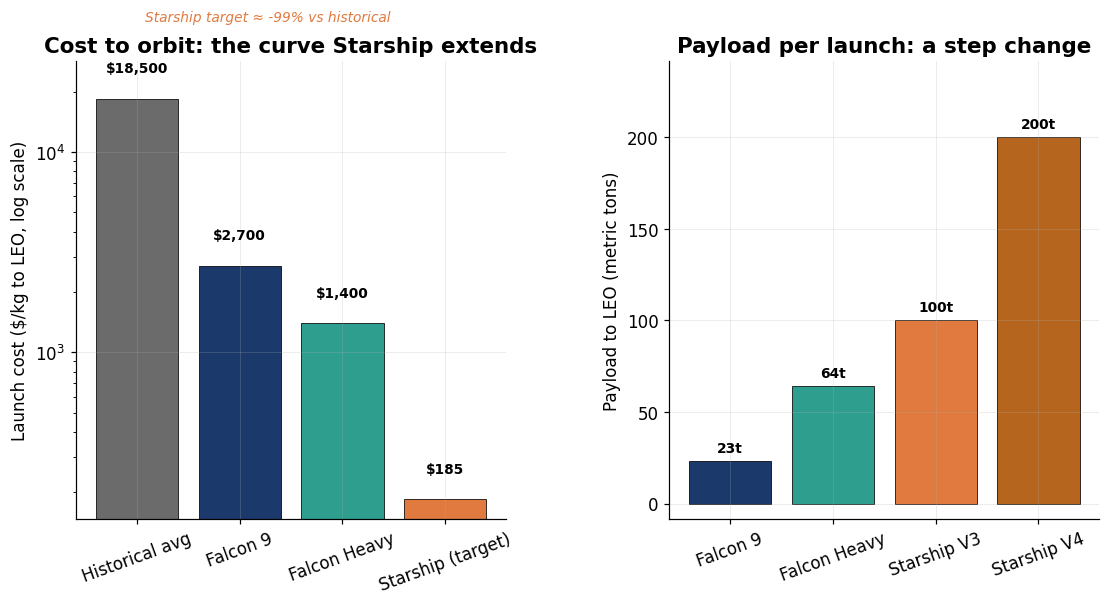

In [9]:
# The S-1's own cost-per-kg curve (log axis) + payload capacity by vehicle.
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12.0, 5.2))

# --- Left panel: cost per kg ---
cost_labels = list(COST_PER_KG.keys())
cost_values = list(COST_PER_KG.values())
cost_colors = [GREY, NAVY, TEAL, ORANGE]

ax_left.bar(cost_labels, cost_values, color=cost_colors, edgecolor="black", linewidth=0.5)
ax_left.set_yscale("log")
ax_left.set_ylabel("Launch cost ($/kg to LEO, log scale)")
ax_left.set_title("Cost to orbit: the curve Starship extends")
ax_left.tick_params(axis="x", labelrotation=20)

for bar_index, value in enumerate(cost_values):
    ax_left.text(bar_index, value * 1.35, f"${value:,.0f}", ha="center", fontsize=9, fontweight="bold")

reduction_vs_historical = 1 - COST_PER_KG["Starship (target)"] / COST_PER_KG["Historical avg"]
fig.text(
    0.27,
    0.97,
    f"Starship target ≈ -{reduction_vs_historical:.0%} vs historical",
    ha="center",
    fontsize=9,
    style="italic",
    color=ORANGE,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.92, edgecolor="none"),
)

# --- Right panel: payload per launch ---
payload_labels = list(PAYLOAD_T_LEO.keys())
payload_values = list(PAYLOAD_T_LEO.values())
payload_colors = [NAVY, TEAL, ORANGE, "#b5651d"]

ax_right.bar(payload_labels, payload_values, color=payload_colors, edgecolor="black", linewidth=0.5)
ax_right.set_ylabel("Payload to LEO (metric tons)")
ax_right.set_title("Payload per launch: a step change")
ax_right.tick_params(axis="x", labelrotation=20)

for bar_index, value in enumerate(payload_values):
    ax_right.text(bar_index, value + 5, f"{value}t", ha="center", fontsize=9, fontweight="bold")

charts.finish_pair(fig, wspace=0.38, top=0.90)
charts.pad_ylim(ax_left, top=0.22)
charts.pad_ylim(ax_right, top=0.15)
charts.save(fig, "space_cost_curve", layout=False)
plt.show()


In [10]:
# Why Starship is mandatory for orbital AI: cost to lift the S-1's ~1,000,000 t/yr target.
TARGET_T_YR = 1_000_000
target_kg = TARGET_T_YR * 1_000

falcon_heavy_cost_per_kg = COST_PER_KG["Falcon Heavy"]
starship_cost_per_kg = COST_PER_KG["Starship (target)"]

cost_falcon_heavy_b = target_kg * falcon_heavy_cost_per_kg / 1e9
cost_starship_b = target_kg * starship_cost_per_kg / 1e9

ai = pd.Series({
    "At Falcon Heavy ($1,400/kg)": cost_falcon_heavy_b,
    "At Starship target ($185/kg)": cost_starship_b,
}, name="$B/yr to lift 1,000,000 t")

display(ai.round(0).to_frame())

reduction = 1 - cost_starship_b / cost_falcon_heavy_b
print(
    f"Lifting the S-1's orbital-AI mass target costs ~${cost_falcon_heavy_b:,.0f}B/yr on Falcon Heavy vs "
    f"~${cost_starship_b:,.0f}B/yr on Starship —"
)
print(f"a {reduction:.0%} reduction. Orbital AI compute is an economic non-starter without Starship.")


,"$B/yr to lift 1,000,000 t"
"At Falcon Heavy ($1,400/kg)",1400.0
At Starship target ($185/kg),185.0


Lifting the S-1's orbital-AI mass target costs ~$1,400B/yr on Falcon Heavy vs ~$185B/yr on Starship —
a 87% reduction. Orbital AI compute is an economic non-starter without Starship.


### 5.1 But customer demand is flat — so why does more capacity matter?

The honest objection to everything above: SpaceX's *customer* launch count is flat-to-falling (43 in
FY2025, a ~25-launch run-rate in Q1-2026), and the S-1 openly says it **backfills otherwise-idle
launch slots with Starlink**. If SpaceX already has more launch capacity than paying customers want,
how does a rocket that lifts *even more* mass add a single dollar of revenue? A bigger firehose is
useless if the bucket is already full.

It's the right question, and it kills the lazy bull case ("Starship = 10× the launches = 10× Space
revenue"). That story is wrong: the customer launch market is **demand-constrained**, and Starship
does nothing for demand SpaceX can't already serve with Falcon. What Starship actually changes is
*which businesses are physically and economically possible* once \$/kg falls ~85–90% — and those
businesses are mostly **SpaceX's own**:

- **Orbital AI compute → the AI segment.** The S-1's vision (~1M tons/yr to orbit for ~100 GW of
  compute) is **mass-constrained, not demand-constrained**: the appetite for AI compute is effectively
  unlimited; the blocker is the cost of lifting power+silicon to orbit. At Falcon Heavy's \$1,400/kg
  it's a ~\$1.4T/yr fantasy; at Starship's target it might pencil. Starship is the *precondition* — but
  the revenue books in **AI**, not Space.
- **Next-gen Starlink → the Connectivity segment (the flywheel).** Bigger, heavier V2/V3 satellites
  (more capacity and direct-to-cell per bird) only make sense with cheap, high-cadence launch. The
  Connectivity notebook's **§7.7 affordability–cost flywheel** makes this explicit: as internal launch
  cost glides toward **~\$8M/launch** (vs **\$17.5M** on Falcon today), ARPU can fall faster, the
  reachable subscriber ceiling **expands**, and margin is *computed* from cheaper deployment — not held
  flat. That is **elastic internal demand** (more subs at lower price because launch got cheaper). It
  never appears as Space revenue; it books in **Connectivity** FCF.
- **Genuinely new external demand → the Space segment.** A slice of demand *is* price-elastic and
  simply doesn't close at Falcon prices: third-party mega-constellations, heavy national-security
  payloads, lunar/Mars and NASA Artemis (HLS). This is real *new* Space revenue — and it's the
  **smallest** of the three.

So the defensible read: **Starship is an infrastructure bet whose payoff is collected mostly in AI and
Connectivity, plus a modest new external launch market in Space.** For the Space segment in isolation,
the dominant effect isn't a wall of new revenue — it's the **mechanical reversal of the ~\$2.5B R&D
drag** when Starship capitalizes (§4 hinge). The §6 model is built to respect this: external Starship
revenue stays deliberately modest, and we refuse to book the internal payoff here (that would
double-count what belongs to the other two segments).

### 5.2 How much of the Starship story do we actually believe?

SpaceX is the one company whose audacious cost claims have earned *partial* credit — it has done the
implausible twice (Falcon 9, then Falcon Heavy reuse). But *"designed to"* and *"we aim to"* are not
*"we did,"* and the genuinely hard part — a rapidly reusable upper stage at high cadence — is exactly
what has historically slipped. So we grade the S-1's claims and treat each accordingly:

| S-1 claim | Status | How we treat it |
|---|---|---|
| Falcon 9 / Heavy reuse → ~\$2,700 / \$1,400 per kg; >80% of world mass to orbit | **Demonstrated** | Take as fact — audited operating history. |
| Booster catch & reuse on Starship | **Demonstrated (early)** | Capability is real; reliability and rapid refly are not yet proven. |
| Starship V3 delivers ~100t reusable (200t future) | **Design target** | Plausible, not shown. Treat as a *ceiling* the cadence ramps toward. |
| ≥99% cost cut → ~\$185/kg | **Aspirational** | Directional, not a base case. We assume a large *but smaller* cut. |
| ~1M tons/yr → 100 GW orbital compute | **Vision / TAM marketing** | A flourish, not a forecast. ~Zero credit in Space; only cautious credit in AI. |
| *When* Starship serves commercial payloads | **Not disclosed** | Our scenario lever — the catalyst that separates bear / base / bull (§6). |

**Our stance:** demonstrated economics = fact; design targets = ramps, not step-functions;
visionary tonnage = upside we do not underwrite. That keeps the jokes as garnish and the model honest.

The cost curve is the whole thesis in one picture: Starship isn't a bigger Falcon, it's the asset that
makes SpaceX's two *other* segments (mass-hungry Starlink, absurdly mass-hungry orbital AI) economically
possible — which is why its value mostly shows up *there*, not in Space (§5.1). For the Space segment,
the capitalize-at-commercialization rule means the day Starship starts flying paying payloads is the
day the reported P&L stops bleeding. So the question that actually moves the Space valuation isn't
*how much* — it's **when**. That timing is the catalyst we vary next.

## 6. Modeling Starship revenue — the catalyst is *timing*

The one fact the S-1 won't give us is **when** Starship serves paying payloads — and per §4–§5 that
date is what actually swings the Space valuation, because it's when the ~\$2.5B R&D drag flips to
capitalized cost. So we define the scenarios by a **commercialization year** and attach **concrete,
falsifiable milestones** to each. Everything else (cadence ramp, external pricing, growth) is a
*consequence* of how fast and how well the program matures — not an independent dial.

| Catalyst | 🐻 **Bear — 2029** | **Base — 2028** | 🐂 **Bull — 2027** |
|---|---|---|---|
| Full-stack reuse (booster **+ ship**, rapid refly) | slips; ship reuse stays hard, anomalies recur | demonstrated by 2027, refurb slower than hoped | reliable & rapid by 2026 |
| Payload to LEO at commercialization | well under design (~50–70t) | ramping toward 100t | ~100t, V3 on spec |
| Regulatory / pads (FAA cadence, 2nd pad at Cape) | environmental & cadence delays | Starbase scaled, Cape coming online | multi-pad high-cadence approved |
| First commercial payloads | 2029 | 2028 | 2027; NASA HLS milestones hit |
| External \$/kg vs Falcon | only modestly better | clearly better, not yet "the dream" | approaching the low hundreds |
| **Net effect on Space** | Starship ≈ internal tool; thin external market | real new external lift + internal scale | earlier commercial payloads; still modest *external* revenue (flywheel is internal) |

These map to model levers (all assumptions, flagged): the **commercialization year**, an **external-
mission ramp** and **price per mission**, and how fast **R&D normalizes**. Keep the §5.1 caveat in
view — external Starship revenue is deliberately kept modest (demand-constrained), so the scenario
spread is driven mostly by *timing of the R&D reversal* plus a small, genuinely-new external market.
The big internal payoff is credited in the AI and Connectivity notebooks, not here.

In [11]:
# ---- Forward Space-segment scenarios (canonical: analysis.space_economics) ----
from analysis.space_economics import project_space_forward, SPACE_SCENARIOS, SS_YEAR

FWD = ["FY2026E", "FY2027E", "FY2028E", "FY2029E", "FY2030E"]
YRS = [2026, 2027, 2028, 2029, 2030]


def _to_period_labels(df):
    out = df.copy()
    period_labels = [f"FY{year}E" for year in out.index]
    out.index = period_labels
    out.index.name = "period"
    return out


# Chart-only overlays (not in the module — colors + narrative catalysts).
scen = {}
scenario_styles = [
    ("Bear", GREY, "ship reuse slips; FAA / environmental delays"),
    ("Base", NAVY, "full reuse by 2027; refurb ramps gradually"),
    ("Bull", TEAL, "reliable rapid reuse by 2026; V3 on spec"),
]
for scenario_name, color, catalyst in scenario_styles:
    scen[scenario_name] = {
        **SPACE_SCENARIOS[scenario_name],
        "color": color,
        "catalyst": catalyst,
    }

proj = {}
for scenario_name in scen:
    raw_projection = project_space_forward(scenario_name)
    proj[scenario_name] = _to_period_labels(raw_projection)

summary = pd.DataFrame(index=list(scen))
summary["Commercial year"] = [str(scen[s]["commercial_year"]) for s in scen]
summary["Catalyst"] = [scen[s]["catalyst"] for s in scen]
summary["FY2030E revenue ($M)"] = [proj[s].loc["FY2030E", "revenue"] for s in scen]
summary["FY2030E ext. Starship ($M)"] = [proj[s].loc["FY2030E", "ss_rev"] for s in scen]
summary["FY2030E op income ($M)"] = [proj[s].loc["FY2030E", "op_income"] for s in scen]

print("SCENARIO SUMMARY (catalyst = commercialization timing):")
display(fmt(summary))

print("\nBASE CASE detail (commercialization 2028):")
base_detail_cols = [
    "cust_rev", "ld_rev", "ss_launches", "ss_rev", "revenue", "rnd", "op_income", "op_margin",
]
display(fmt(proj["Base"][base_detail_cols], pct=["op_margin"], one=["ss_launches"]))

oi = pd.DataFrame({name: proj[name]["op_income"] for name in scen}, index=FWD)
oi.loc["FY2025 (actual)"] = R.op_income["FY2025"]
oi = oi.reindex(["FY2025 (actual)"] + FWD)
print("\nSpace segment operating income by scenario ($M):")
display(fmt(oi))


SCENARIO SUMMARY (catalyst = commercialization timing):


,Commercial year,Catalyst,FY2030E revenue ($M),FY2030E ext. Starship ($M),FY2030E op income ($M)
Bear,2029,ship reuse slips; FAA / environmental delays,"4,845",210,433
Base,2028,full reuse by 2027; refurb ramps gradually,"6,195",990,"2,596"
Bull,2027,reliable rapid reuse by 2026; V3 on spec,"7,700","1,980","3,603"



BASE CASE detail (commercialization 2028):


,cust_rev,ld_rev,ss_launches,ss_rev,revenue,rnd,op_income,op_margin
period,,,,,,,,
FY2026E,"2,653","1,631",0.0,0,"4,284","3,720","-1,202",-28.1%
FY2027E,"2,733","1,761",0.0,0,"4,494","3,720","-1,062",-23.6%
FY2028E,"2,815","1,902",3.0,270,"4,987","3,720",-732,-14.7%
FY2029E,"2,899","2,054",6.0,540,"5,494","2,460",867,15.8%
FY2030E,"2,986","2,219",11.0,990,"6,195","1,200","2,596",41.9%



Space segment operating income by scenario ($M):


,Bear,Base,Bull
FY2025 (actual),-657,-657,-657
FY2026E,"-1,267","-1,202","-1,148"
FY2027E,"-1,197","-1,062",-725
FY2028E,"-1,124",-732,973
FY2029E,-977,867,"2,835"
FY2030E,433,"2,596","3,603"


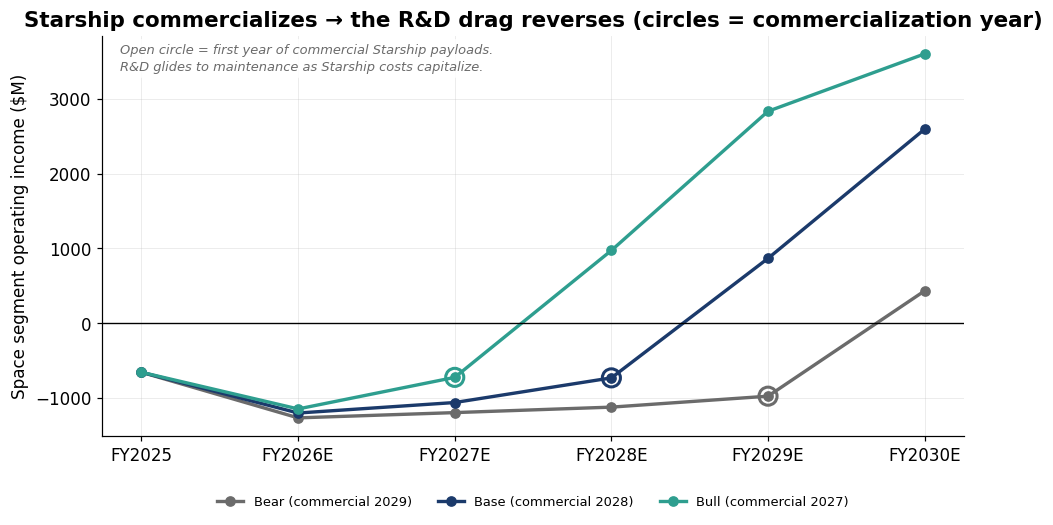

In [12]:
# The op-income flip: the Starship R&D drag reverses as the program commercializes.
fig, ax = plt.subplots(figsize=(8.8, 5.2))
x_labels = ["FY2025"] + FWD
fy2025_op_income = R.op_income["FY2025"]

for scenario_name, cfg in scen.items():
    forward_op_income = list(proj[scenario_name]["op_income"].values)
    y_values = [fy2025_op_income] + forward_op_income
    line_color = cfg["color"]
    commercial_year = cfg["commercial_year"]

    ax.plot(
        x_labels,
        y_values,
        marker="o",
        linewidth=2.2,
        color=line_color,
        label=f"{scenario_name} (commercial {commercial_year})",
    )

    if commercial_year in YRS:
        year_index = YRS.index(commercial_year)
        x_marker = FWD[year_index]
        y_marker = proj[scenario_name]["op_income"].loc[x_marker]
        ax.scatter(
            [x_marker],
            [y_marker],
            s=140,
            facecolors="none",
            edgecolors=line_color,
            linewidth=2,
            zorder=5,
        )

ax.axhline(0, color="black", linewidth=0.9)
ax.set_ylabel("Space segment operating income ($M)")
ax.set_title("Starship commercializes → the R&D drag reverses (circles = commercialization year)")

# Footnote in the empty top-left of the plot; legend below the x-axis labels.
caption = (
    "Open circle = first year of commercial Starship payloads.\n"
    "R&D glides to maintenance as Starship costs capitalize."
)
ax.text(
    0.02,
    0.98,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    style="italic",
    color=GREY,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.88, edgecolor="none"),
    zorder=10,
)

legend_handles, legend_labels = ax.get_legend_handles_labels()
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    fontsize=8.5,
    frameon=False,
)

fig.subplots_adjust(top=0.90, bottom=0.20, left=0.09, right=0.98)
charts.save(fig, "space_starship_scenarios", layout=False)
plt.show()


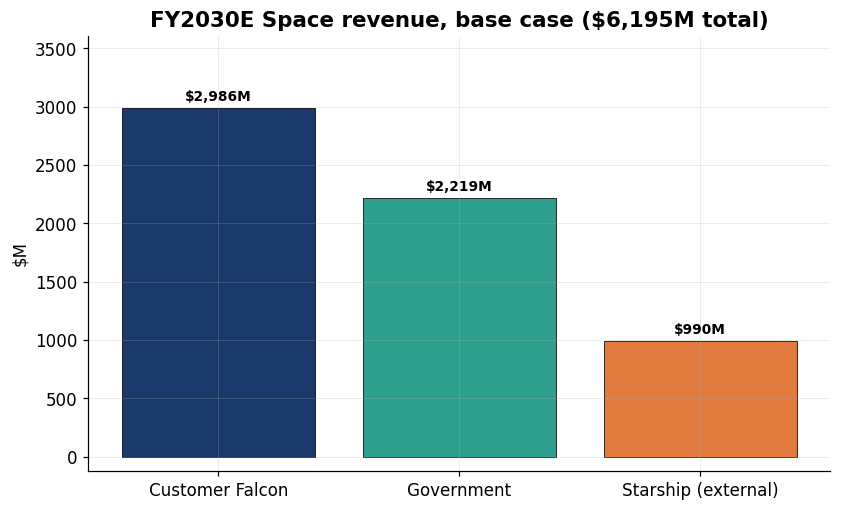

Base-case FY2030E Space revenue $6,195M, of which external Starship $990M (16%).
Even in the model, external Starship revenue is the SMALLER prize — the big one (cheap internal
deployment of Starlink + AI compute) shows up in the Connectivity and AI segments, not here.


In [13]:
# Where the FY2030 revenue comes from (base case): customer Falcon, government, Starship external.
base_2030 = proj["Base"].loc["FY2030E"]

build = pd.Series({
    "Customer Falcon": base_2030["cust_rev"],
    "Government": base_2030["ld_rev"],
    "Starship (external)": base_2030["ss_rev"],
}, name="FY2030E Space revenue ($M)")

fig, ax = plt.subplots(figsize=(7.8, 4.8))
bar_colors = [NAVY, TEAL, ORANGE]
bars = ax.bar(build.index, build.values, color=bar_colors, edgecolor="black", linewidth=0.5)

for bar_index, value in enumerate(build.values):
    ax.text(bar_index, value + 60, f"${value:,.0f}M", ha="center", fontsize=9, fontweight="bold")

ax.set_ylabel("$M")
total_revenue = build.sum()
ax.set_title(f"FY2030E Space revenue, base case (${total_revenue:,.0f}M total)")
charts.finish(fig)
charts.pad_ylim(ax, top=0.15)
charts.save(fig, "space_fy2030_revenue_build", layout=False)
plt.show()

starship_share = base_2030["ss_rev"] / total_revenue
print(
    f"Base-case FY2030E Space revenue ${total_revenue:,.0f}M, of which external Starship "
    f"${base_2030['ss_rev']:,.0f}M ({starship_share:.0%})."
)
print("Even in the model, external Starship revenue is the SMALLER prize — the big one (cheap internal")
print("deployment of Starlink + AI compute) shows up in the Connectivity and AI segments, not here.")


**What this sets up (§7 closes to cash).** Four takeaways the Space-segment forecast should carry forward:

1. **The franchise floor.** Even crediting Starship *nothing*, the customer-launch + government book is
   a structurally profitable business once you stop expensing Starship against it (§4) — the downside
   support for the segment regardless of how the rocket goes.
2. **Timing is the catalyst, not magnitude.** The bear/base/bull spread is driven mostly by *when* the
   ~\$2.5B R&D drag reverses (§4 hinge), which is why we keyed the scenarios to commercialization year:
   a 2027 vs 2029 start is the difference between the segment turning the corner mid-decade (~\$4B op
   income by FY2030) or barely breaking even (~\$0.4B).
3. **External Starship revenue stays a slice — on purpose.** Customer Falcon demand is flat
   (§5.1); the §7.7 flywheel's demand surge is *internal* and books in Connectivity. We hold *external*
   Starship revenue modest even in bull (~\$0.2–2B by FY2030 vs ~\$3–6B from the legacy franchise).
   Starship's dominant value — the ~85–90% collapse in internal deployment cost — is credited in the
   **AI and Connectivity** segments, not double-counted here.
4. **Discount the vision, keep the mechanics.** Per the credibility ledger (§5.2), we underwrite the
   demonstrated economics and the (mechanical) R&D reversal, and we do *not* underwrite the \$185/kg
   dream or the 1M-tons/yr orbital-compute TAM. If those land, they're upside — mostly to other segments.

The one-line summary holds, sharpened: **Space is a profitable launch monopoly wearing a Starship-
shaped loss, and the only question that moves its valuation is when that loss converts into an asset.**

## 7. Forward free cash flow — Starship commercialization in cash terms

§6 showed operating income flipping positive when Starship **commercializes** (R&D expensed today
capitalizes tomorrow) and a **modest** external launch book ramps on top of the Falcon franchise.
This section closes the same paths to **free cash flow** — the number a DCF discounts.

$$\text{FCF} = \text{operating income} + \text{D\&A} + \text{SBC} - \text{capex}$$

Same definition as Connectivity §3/§8 and ``analysis/dcf.py``. FY2025 is anchored to reported
Space fundamentals; FY2026–FY2030 use the canonical engine in ``analysis.space_economics``
(also what ``dcf.py`` calls for the Space segment).

**What Starship does *here* (Space segment only).**
1. **R&D spend falls** after commercialization — the ~\$3.7B run-rate glides to ~\$1.2B maintenance;
   that is the dominant cash swing in operating income.
2. **A thin external revenue ramp** — ``SS_RAMP`` missions × scenario price; price-elastic demand
   that does not close on Falcon (§5.1).
3. **Capex still rises** through FY2030 (Starship tooling + fleet); D&A rises too once development
   capitalizes. So Space FCF can stay **negative** even as op income recovers — the segment is
   mid-build, not a cash cow yet.

**What Starship does *there* (Connectivity — the big prize).** Cheaper internal launches
(§7.7 flywheel in the Connectivity notebook) cut Starlink deployment capex and expand the
subscriber ceiling. That is **not** booked as Space revenue; do not double-count it here.


In [14]:
# FY2025 FCF anchor (reported fundamentals) + forward paths from the canonical engine.
SBC_PCT = R.sbc["FY2025"] / R.revenue["FY2025"]

op_income_25 = R.op_income["FY2025"]
da_25 = R.da["FY2025"]
sbc_25 = R.sbc["FY2025"]
impairment_25 = R.impairment["FY2025"]
capex_25 = R.capex["FY2025"]
FCF25 = op_income_25 + da_25 + sbc_25 + impairment_25 - capex_25

fcf = {}
for scenario_name in scen:
    raw_fcf = project_space_forward(scenario_name)
    fcf[scenario_name] = _to_period_labels(raw_fcf)

ff25 = pd.Series({
    "Operating income": op_income_25,
    "+ D&A": da_25,
    "+ SBC": sbc_25,
    "- Capex": -capex_25,
    "= FCF": FCF25,
}, name="FY2025 ($M)")
display(fmt(ff25.to_frame().T))

print(
    f"FY2025 Space FCF: ${FCF25:,.0f}M — negative because ${capex_25:,.0f}M capex overwhelms "
    f"the segment even before the full Starship R&D run-rate."
)


,Operating income,+ D&A,+ SBC,- Capex,= FCF
FY2025 ($M),-657,757,515,"-3,832","-3,179"


FY2025 Space FCF: $-3,179M — negative because $3,832M capex overwhelms the segment even before the full Starship R&D run-rate.


In [15]:
# Forward FCF bridge — base case shown; all three scenarios in the chart below.

def fcf_bridge(df):
    bridge = pd.DataFrame(index=df.index)
    bridge["Revenue"] = df["revenue"]
    bridge["Op income"] = df["op_income"]
    bridge["R&D"] = df["rnd"]
    bridge["+ D&A"] = df["da"]
    bridge["+ SBC"] = df["sbc"]
    bridge["- Capex"] = -df["capex"]
    bridge["= FCF"] = df["fcf"]
    bridge["FCF margin"] = df["fcf_margin"]
    return bridge


display(fmt(fcf_bridge(fcf["Base"]), pct=["FCF margin"]))

base_2030 = fcf["Base"].loc["FY2030E"]
bear_2030 = fcf["Bear"].loc["FY2030E"]
starship_cash = pd.Series({
    "Base FY2030 R&D ($M)": base_2030["rnd"],
    "Bear FY2030 R&D ($M)": bear_2030["rnd"],
    "R&D saved vs Bear (Base)": bear_2030["rnd"] - base_2030["rnd"],
    "Base FY2030 ext. Starship rev": proj["Base"].loc["FY2030E", "ss_rev"],
    "Base FY2030 FCF": base_2030["fcf"],
    "Bear FY2030 FCF": bear_2030["fcf"],
}, name="Starship timing → cash (Base vs Bear)")
display(fmt(starship_cash.to_frame().T))


,Revenue,Op income,R&D,+ D&A,+ SBC,- Capex,= FCF,FCF margin
period,,,,,,,,
FY2026E,"4,284","-1,202","3,720",848,540,"-4,254","-4,068",-95.0%
FY2027E,"4,494","-1,062","3,720",950,566,"-4,721","-4,267",-95.0%
FY2028E,"4,987",-732,"3,720","1,064",629,"-5,241","-4,281",-85.8%
FY2029E,"5,494",867,"2,460","2,447",692,"-5,817","-1,811",-33.0%
FY2030E,"6,195","2,596","1,200","2,590",781,"-6,457",-491,-7.9%


,Base FY2030 R&D ($M),Bear FY2030 R&D ($M),R&D saved vs Bear (Base),Base FY2030 ext. Starship rev,Base FY2030 FCF,Bear FY2030 FCF
Starship timing → cash (Base vs Bear),"1,200","2,460","1,260",990,-491,"-1,998"


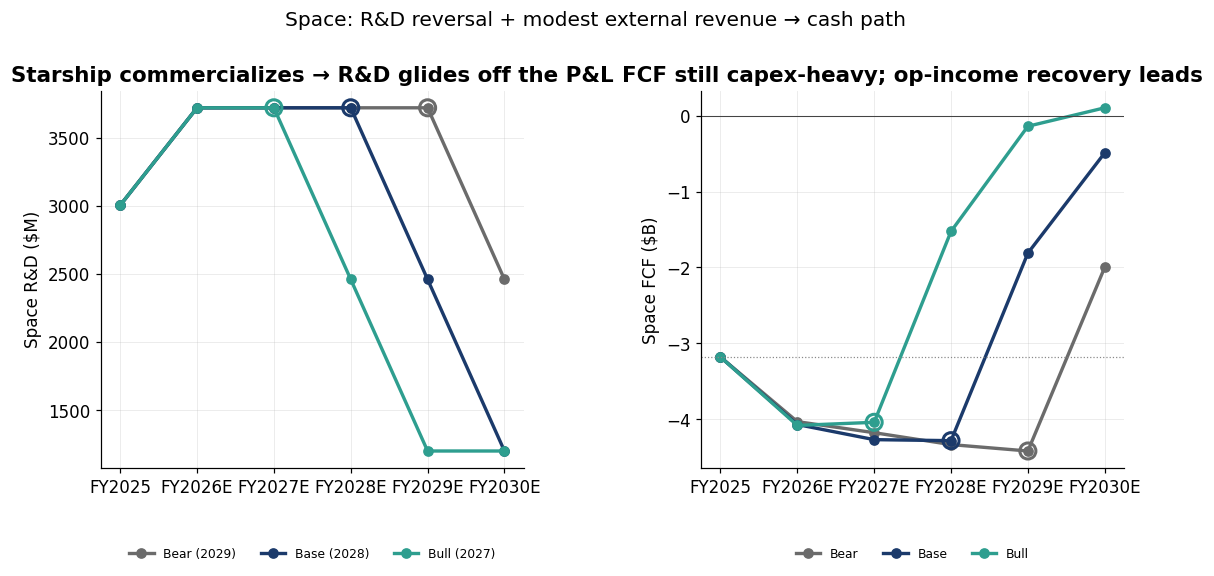

In [16]:
# R&D and FCF paths: commercialization year is the hinge (open circle = first commercial payloads).
fig, (ax_rnd, ax_fcf) = plt.subplots(1, 2, figsize=(12.0, 5.2))
x_labels = ["FY2025"] + FWD
fy2025_rnd = R.rnd["FY2025"]
fy2025_fcf_b = FCF25 / 1000

for scenario_name, cfg in scen.items():
    line_color = cfg["color"]
    commercial_year = cfg["commercial_year"]

    forward_rnd = list(fcf[scenario_name]["rnd"].values)
    rnd_y = [fy2025_rnd] + forward_rnd
    ax_rnd.plot(
        x_labels,
        rnd_y,
        marker="o",
        linewidth=2.2,
        color=line_color,
        label=f"{scenario_name} ({commercial_year})",
    )

    forward_fcf_b = list(fcf[scenario_name]["fcf"].values / 1000)
    fcf_y = [fy2025_fcf_b] + forward_fcf_b
    ax_fcf.plot(
        x_labels,
        fcf_y,
        marker="o",
        linewidth=2.2,
        color=line_color,
        label=f"{scenario_name}",
    )

    if commercial_year in YRS:
        year_index = YRS.index(commercial_year)
        x_marker = FWD[year_index]
        rnd_marker = fcf[scenario_name].loc[x_marker, "rnd"]
        fcf_marker = fcf[scenario_name].loc[x_marker, "fcf"] / 1000
        ax_rnd.scatter(
            [x_marker],
            [rnd_marker],
            s=110,
            facecolors="none",
            edgecolors=line_color,
            linewidth=2,
            zorder=5,
        )
        ax_fcf.scatter(
            [x_marker],
            [fcf_marker],
            s=110,
            facecolors="none",
            edgecolors=line_color,
            linewidth=2,
            zorder=5,
        )

ax_rnd.set_ylabel("Space R&D ($M)")
ax_rnd.set_title("Starship commercializes → R&D glides off the P&L")
ax_rnd.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8, frameon=False)

ax_fcf.axhline(0, color="#444", linewidth=0.7)
ax_fcf.axhline(fy2025_fcf_b, color="#888", linestyle=":", linewidth=0.8)
ax_fcf.set_ylabel("Space FCF ($B)")
ax_fcf.set_title("FCF still capex-heavy; op-income recovery leads")
ax_fcf.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8, frameon=False)

fig.suptitle("Space: R&D reversal + modest external revenue → cash path", y=1.02)
charts.finish_pair(fig, top=0.88, bottom=0.22, wspace=0.42)
charts.save(fig, "space_forward_fcf", layout=False)
plt.show()


,Δ Customer + gov revenue,Δ External Starship rev,Δ R&D,Δ Op income,Δ D&A,Δ SBC,Δ Capex,Δ FCF
Base: FY2025 → FY2030E ($M),"1,119",990,"-1,804","3,253","1,833",266,"2,625","2,688"


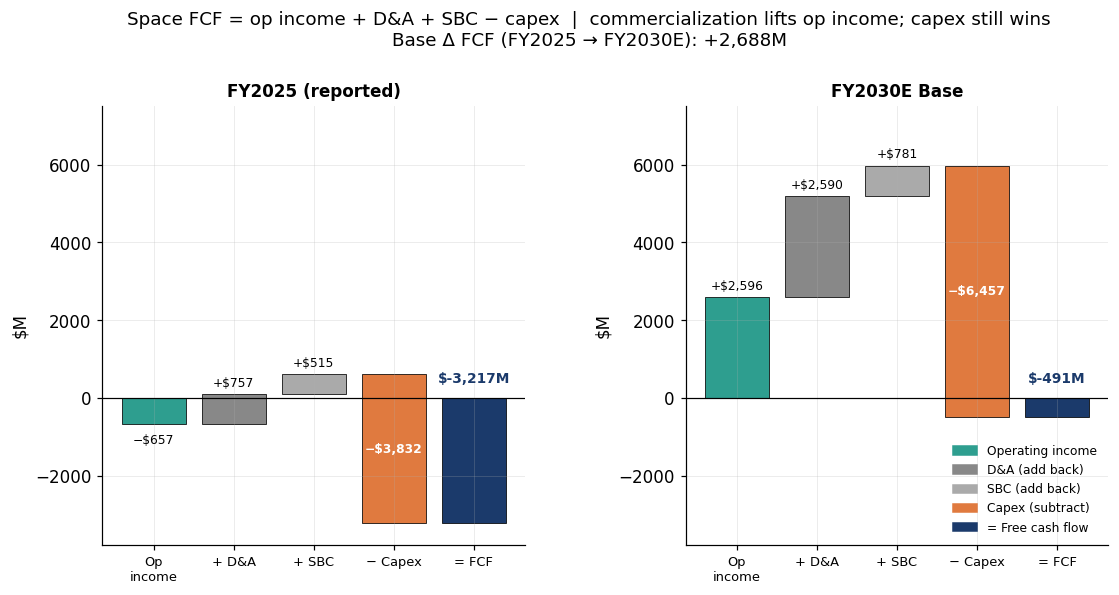

In [17]:
# FY2030 base case: what changed vs FY2025? (exact FCF bridge.)
period_2025 = "FY2025"
period_2030 = "FY2030E"
base_fcf = fcf["Base"]

delta_op_income = base_fcf.loc[period_2030, "op_income"] - R.op_income[period_2025]
delta_da = base_fcf.loc[period_2030, "da"] - R.da[period_2025]
delta_sbc = base_fcf.loc[period_2030, "sbc"] - R.sbc[period_2025]
delta_capex = base_fcf.loc[period_2030, "capex"] - R.capex[period_2025]
delta_fcf = base_fcf.loc[period_2030, "fcf"] - FCF25

rev_2025_cust_gov = R.launch_services[period_2025] + R.launch_dev[period_2025]
rev_2030_cust_gov = proj["Base"].loc[period_2030, "cust_rev"] + proj["Base"].loc[period_2030, "ld_rev"]

decomp = pd.Series({
    "Δ Customer + gov revenue": rev_2030_cust_gov - rev_2025_cust_gov,
    "Δ External Starship rev": proj["Base"].loc[period_2030, "ss_rev"],
    "Δ R&D": base_fcf.loc[period_2030, "rnd"] - R.rnd[period_2025],
    "Δ Op income": delta_op_income,
    "Δ D&A": delta_da,
    "Δ SBC": delta_sbc,
    "Δ Capex": delta_capex,
    "Δ FCF": delta_fcf,
}, name=f"Base: {period_2025} → {period_2030} ($M)")
display(fmt(decomp.to_frame().T))

# Side-by-side FCF builds: same formula each year (self-contained vs a delta waterfall).
def _annotate_step(ax, x, base, height, delta):
    if delta >= 0:
        ax.annotate(
            f"+${delta:,.0f}",
            (x, base + height),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=8,
        )
    elif height >= 900:
        ax.annotate(
            f"−${abs(delta):,.0f}",
            (x, base + height / 2),
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )
    else:
        ax.annotate(
            f"−${abs(delta):,.0f}",
            (x, base),
            textcoords="offset points",
            xytext=(0, -13),
            ha="center",
            fontsize=8,
        )


def _fcf_build_waterfall(ax, op_income, da, sbc, capex, title):
    """FCF = op income + D&A + SBC − capex."""
    steps = [
        ("Op\nincome", op_income, TEAL),
        ("+ D&A", da, "#888"),
        ("+ SBC", sbc, "#aaa"),
        ("− Capex", -capex, ORANGE),
    ]
    running = 0.0
    for i, (label, delta, color) in enumerate(steps):
        base = running if delta >= 0 else running + delta
        ax.bar(i, abs(delta), bottom=base, color=color, edgecolor="k", linewidth=0.5)
        _annotate_step(ax, i, base, abs(delta), delta)
        running += delta

    fcf_val = op_income + da + sbc - capex
    end_i = len(steps)
    ax.bar(end_i, fcf_val, color=NAVY, edgecolor="k", linewidth=0.5)
    if fcf_val >= 0:
        ax.annotate(
            f"${fcf_val:,.0f}M",
            (end_i, fcf_val),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontweight="bold",
            fontsize=9,
        )
    else:
        ax.annotate(
            f"${fcf_val:,.0f}M",
            (end_i, 0),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontweight="bold",
            fontsize=9,
            color=NAVY,
        )

    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xticks(range(end_i + 1))
    ax.set_xticklabels([s[0] for s in steps] + ["= FCF"], fontsize=8.5)
    ax.set_ylabel("$M")
    ax.set_title(title, fontsize=11)
    return fcf_val


fy25 = {
    "op_income": R.op_income[period_2025],
    "da": R.da[period_2025],
    "sbc": R.sbc[period_2025],
    "capex": R.capex[period_2025],
}
fy30 = {
    "op_income": base_fcf.loc[period_2030, "op_income"],
    "da": base_fcf.loc[period_2030, "da"],
    "sbc": base_fcf.loc[period_2030, "sbc"],
    "capex": base_fcf.loc[period_2030, "capex"],
}

fig, (ax25, ax30) = plt.subplots(
    1, 2, figsize=(11.8, 5.4), gridspec_kw={"width_ratios": [1, 1], "wspace": 0.38}
)
_fcf_build_waterfall(ax25, **fy25, title="FY2025 (reported)")
_fcf_build_waterfall(ax30, **fy30, title="FY2030E Base")

for ax in (ax25, ax30):
    charts.pad_ylim(ax, top=0.18, bottom=0.14)
ylim = (min(ax25.get_ylim()[0], ax30.get_ylim()[0]), max(ax25.get_ylim()[1], ax30.get_ylim()[1]))
ax25.set_ylim(ylim)
ax30.set_ylim(ylim)

fig.suptitle(
    "Space FCF = op income + D&A + SBC − capex  |  commercialization lifts op income; capex still wins\n"
    f"Base Δ FCF (FY2025 → FY2030E): {delta_fcf:+,.0f}M",
    y=1.04,
    fontsize=12,
)
ax30.legend(
    handles=[
        Patch(color=TEAL, label="Operating income"),
        Patch(color="#888", label="D&A (add back)"),
        Patch(color="#aaa", label="SBC (add back)"),
        Patch(color=ORANGE, label="Capex (subtract)"),
        Patch(color=NAVY, label="= Free cash flow"),
    ],
    loc="lower right",
    fontsize=8,
)
charts.finish_pair(fig, top=0.88, bottom=0.14, wspace=0.38)
charts.save(fig, "space_fcf_decomposition", layout=False)
plt.show()


In [18]:
# Square with analysis/dcf.py (must match — same project_space_forward engine).
from analysis import dcf

actuals = dcf._actuals()
dcf_space = {}
for scenario_name in scen:
    dcf_space[scenario_name] = dcf.project_segments(scenario_name, actuals)["Space"]

notebook_fcf = []
dcf_py_fcf = []
delta_fcf = []
for scenario_name in scen:
    notebook_value = fcf[scenario_name].loc["FY2030E", "fcf"]
    dcf_value = dcf_space[scenario_name].loc[2030, "fcf"]
    notebook_fcf.append(notebook_value)
    dcf_py_fcf.append(dcf_value)
    delta_fcf.append(notebook_value - dcf_value)

chk = pd.DataFrame({
    "Notebook FCF": notebook_fcf,
    "dcf.py FCF": dcf_py_fcf,
    "Δ ($M)": delta_fcf,
}, index=list(scen))
display(fmt(chk, one=["Δ ($M)"]))
assert (chk["Δ ($M)"].abs() < 0.01).all(), "space.ipynb FCF must match dcf.py"

cumulative_fcf_b = {}
for scenario_name in scen:
    cumulative_fcf_b[scenario_name] = fcf[scenario_name].loc[FWD[0]:, "fcf"].sum() / 1000

cum = pd.Series(cumulative_fcf_b, name="Cum. FCF FY2026-30 ($B)")
print("Cumulative explicit-period Space FCF (still small vs Connectivity):")
display(fmt(cum.to_frame().T, one=["Cum. FCF FY2026-30 ($B)"]))


,Notebook FCF,dcf.py FCF,Δ ($M)
Bear,"-1,998","-1,998",0.0
Base,-491,-491,0.0
Bull,103,103,0.0


Cumulative explicit-period Space FCF (still small vs Connectivity):


,Bear,Base,Bull
Cum. FCF FY2026-30 ($B),-19,-15,-10


**Space FCF in one sentence.** Starship commercialization is a **P&L and R&D accounting
event first** and a **cash event second**: R&D falling ~\$2.5B/yr lifts operating income sharply, but
**capex still outruns the franchise** through FY2030, so segment FCF remains negative in bear/base and
only turns barely positive in bull (~\$0.1B in FY2030). The DCF values Space on the **terminal**
normalized path (capex → maintenance), not this mid-build explicit period — see ``dcf.ipynb``.

**For the group model.** The funding story is unchanged: Connectivity's Starship dividend (cheaper
satellite deployment) is orders of magnitude larger than Space's own FCF. This section exists so the
Space notebook and ``dcf.py`` share one auditable cash bridge — R&D down, a little more commercial
revenue, capex/D&A still in flight.

## Open threads
- **Starship R&D share** is the single biggest assumption (§4); the S-1 anchors only the \$1,169M
  FY2024→25 *increment* as Starship. A disclosed Falcon-vs-Starship R&D split would tighten the
  franchise-earnings band materially.
- **Commercialization timing** (§6) is judgment, not disclosure. Track Starship V3 flight-test
  cadence and the first capitalized (vs expensed) Starship costs in future filings as the real signal.
- **Customer A concentration** — ~21% of *total* company revenue (FY2025), spanning all three
  segments, almost certainly the U.S. government; worth isolating how much rides in Space's Launch &
  Development book.
- **Dragon / crew** economics are bundled inside Launch Services here; a dedicated split (crew vs
  cargo vs Falcon) would sharpen the unit economics in §3.
- **Internal-deployment value of Starship** is quantified in §5 as a cost-curve and in Connectivity
  **§7.7** as a coupled flywheel (launch cost → ceiling → subs → computed margin). The full payoff
  belongs there and in AI — not in Space revenue (§5.1, §6).